<a href="https://colab.research.google.com/github/Ginkno/postech-tech-challenge-fase2-grupo1-12dtat/blob/Silvia/notebooks/02_preprocessamento-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Pré-processamento

**Dimensão 4 da rúbrica — 15 pontos.**

Cada decisão precisa de justificativa escrita. Decidir *não* criar features é
aceitável, desde que o motivo esteja explícito.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("../data/raw/application_record.csv")
RAW_2 = Path("../data/raw/credit_record.csv")

PROCESSED = Path("../data/processed")
TARGET = "IS_BAD_PAYER"


pd.set_option("display.max_columns", None)

In [21]:
#Leitura do dataframe e visualização das cinco primeiras linhas.

df_application = pd.read_csv(RAW_1)
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## 1. Dados faltantes

In [22]:
#Verificando a existência de dados nulos.

df_application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Verificando a existência de dados nulos e como resultado trouxe que a coluna OCCUPATION_TYPE possui 134203 linhas em branco.

In [23]:
#Substituir os dados em branco da variável OCCUPATION_TYPE por "Unknown".

df_application["OCCUPATION_TYPE"] = df_application["OCCUPATION_TYPE"].fillna("Unknown")

**Decisão:** Para que não haja dados em branco na coluna OCCUPATION_TYPE substituímos por 'Unknow'.

In [24]:
#Converter dias de nascimento para idade em anos e para inteiro.
df_application["YEARS_BIRTH"] = (df_application["DAYS_BIRTH"] / -365).astype(int)

#Criar a coluna IS_INACTIVE (1 para inativo, 0 para empregado).
df_application["IS_INACTIVE"] = (df_application["DAYS_EMPLOYED"] == 365243).astype(int)

#Converter dias de emprego para anos.
df_application["YEARS_EMPLOYED"] = (df_application["DAYS_EMPLOYED"] / -365 ).astype(int)

In [25]:
# Contar quantas vezes o valor -1000 aparece em YEARS_EMPLOYED
count_minus_1000 = (df_application['YEARS_EMPLOYED'] == -1000).sum()
print(f"Quantidade de registros com YEARS_EMPLOYED == -1000: {count_minus_1000}")

# Verificar a relação entre YEARS_EMPLOYED == -1000 e IS_INACTIVE
print("Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:")
display(df_application.loc[df_application['YEARS_EMPLOYED'] == -1000, 'IS_INACTIVE'].value_counts())

Quantidade de registros com YEARS_EMPLOYED == -1000: 75329
Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:


IS_INACTIVE
1    75329
Name: count, dtype: int64

Como esperado, o valor -1000 em YEARS_EMPLOYED corresponde exatamente aos registros onde IS_INACTIVE é 1, ou seja, aos 'pensionistas/inativos'. Para facilitar a análise e a modelagem, substituiremos esse valor por 0, indicando zero anos de emprego ativo, o que é consistente com a definição de inatividade.

In [26]:
# Substituir -1000 em YEARS_EMPLOYED por 0
df_application['YEARS_EMPLOYED'] = df_application['YEARS_EMPLOYED'].replace(-1000, 0)

# Verificar as primeiras linhas após a substituição
print("df_application.head() após substituição de -1000 por 0:")
display(df_application.head())

df_application.head() após substituição de -1000 por 0:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [27]:
#Leitura do dataframe e visualização das cinco primeiras linhas.
df_credit = pd.read_csv(RAW_2)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [28]:
#Verificando a existência de dados nulos.

df_credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

Como resultado trouxe que a quantidade de dados nulos é 0.

In [29]:
#Verificando a existência de dados duplicados.

df_credit.duplicated().sum()

np.int64(0)

In [30]:
print(df_credit['ID'].nunique())
print(len(df_credit))

45985
1048575


## 2. Definição da variável alvo

_Se houve binarização, qual limiar e por quê? Justifique com base na distribuição, não por convenção._

Conforme dicionário de dados disponibilizado: 0: 1-29 dias atrasados; 1: 30-59 dias atrasados; 2: 60-89 dias atrasados; 3: 90-119 dias atrasados; 4: 120-149 dias atrasados; 5: dívidas atrasadas ou incobráveis, perdas por mais de 150 dias; C: quitadas naquele mês; X: sem empréstimo no mês;

Definição da Variável Alvo: `IS_BAD_PAYER`

A variável alvo `IS_BAD_PAYER` foi definida para identificar clientes que apresentaram um **atraso de 60 dias ou mais (ou seja, STATUS de 2 a 5)** em seu histórico de crédito completo.

A utilização do histórico completo permite mapear de forma fidedigna o perfil comportamental de risco de crédito do cliente:
-   **`IS_BAD_PAYER = 1` (Mau Pagador):** Se o cliente possui qualquer ocorrência de `STATUS` '2', '3', '4' ou '5' (atraso de 60 dias ou mais grave).
-   **`IS_BAD_PAYER = 0` (Bom Pagador):** Caso contrário.

Esta lógica foca na gravidade do atraso, estabelecendo uma clara diferenciação entre clientes com desvios pontuais e clientes com atrasos severos no histórico.

In [31]:
# Identificar se o cliente já teve algum status de atraso entre '2' e '5'
status_bad = ['2', '3', '4', '5']

# Agrupar por ID e verificar se há alguma ocorrência desses status
clientes_bad_payer = df_credit.groupby('ID')['STATUS'].apply(lambda x: int(x.isin(status_bad).any())).reset_index()
clientes_bad_payer.rename(columns={'STATUS': 'IS_BAD_PAYER'}, inplace=True)

# Calcular quantidade e proporção para a visualização
counts = clientes_bad_payer['IS_BAD_PAYER'].value_counts()
proportions = clientes_bad_payer['IS_BAD_PAYER'].value_counts(normalize=True) * 100

# Criar um DataFrame consolidado
distribuicao = pd.DataFrame({
    'Quantidade': counts,
    'Proporção (%)': proportions.map('{:.2f}%'.format)
})

print("Distribuição da nova IS_BAD_PAYER baseada no histórico completo:")
display(distribuicao)
display(clientes_bad_payer.head())

Distribuição da nova IS_BAD_PAYER baseada no histórico completo:


,Quantidade,Proporção (%)
IS_BAD_PAYER,,
0,45318,98.55%
1,667,1.45%


,ID,IS_BAD_PAYER
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


### Interpretação da Distribuição Inicial do Histórico de Crédito

A tabela acima apresenta a volumetria obtida a partir da aplicação da lógica de binarização sobre a base de histórico de créditos (`df_credit`):

* **Desbalanceamento Severo:** Observamos que a grande maioria absoluta dos clientes registrados no histórico de pagamentos apresenta um perfil classificado como **Bom Pagador (0)**, enquanto uma fração extremamente reduzida atinge o critério de atraso igual ou superior a 60 dias para ser categorizada como **Mau Pagador (1)**.
* **Justificativa do Critério Técnico:** Esta distribuição valida a nossa escolha de utilizar o histórico completo de comportamento para a rotulação. Caso utilizássemos um critério mais brando (como atrasos de apenas 30 dias), correríamos o risco de classificar erroneamente clientes com pequenos atrasos pontuais e operacionais como de alto risco. O limiar de 60 dias captura de forma realista a inadimplência severa e o risco financeiro de fato.

### Consolidação das Bases: Cadastro (`df_application`) e Variável Alvo (`clientes_bad_payer`)

Agora que definimos a classificação de risco individual de cada cliente com base no seu histórico de pagamentos (`clientes_bad_payer`), precisamos cruzar essas informações com a base cadastral de solicitantes (`df_application`).

Essa consolidação será realizada utilizando a estratégia de **INNER JOIN**. Essa escolha é indispensável pelo seguinte motivo de negócio:
- **Ausência de histórico impossibilita a definição da classe alvo**: Clientes que constam no cadastro de solicitação, mas que não possuem qualquer histórico financeiro registrado na base de crédito, não têm como ter o comportamento avaliado e, portanto, não podem ter sua variável alvo (`IS_BAD_PAYER`) definida.
- Para treinar o modelo preditivo de forma correta e sem viés de dados faltantes na variável dependente, devemos prosseguir apenas com os registros de clientes que possuam tanto os atributos cadastrais quanto o rótulo de pagamento determinado.


In [32]:
# Realizar a consolidação através de um INNER JOIN usando a coluna 'ID'
df_final = pd.merge(df_application, clientes_bad_payer, on='ID', how='inner')

# Exibir volumetria e número de clientes únicos de cada base
print(f"Tamanho da base de cadastro original (df_application): {df_application.shape}")
print(f"Clientes únicos em df_application: {df_application['ID'].nunique()}")

print(f"\nTamanho da base com a variável alvo (clientes_bad_payer): {clientes_bad_payer.shape}")
print(f"Clientes únicos em clientes_bad_payer: {clientes_bad_payer['ID'].nunique()}")

print(f"\nTamanho da base final após o INNER JOIN (df_final): {df_final.shape}")
print(f"Clientes únicos em df_final: {df_final['ID'].nunique()}")

# Exibir a volumetria e proporção final da variável alvo na base consolidada
counts_consolidated = df_final['IS_BAD_PAYER'].value_counts()
proportions_consolidated = df_final['IS_BAD_PAYER'].value_counts(normalize=True) * 100

distribuicao_consolidada = pd.DataFrame({
    'Quantidade': counts_consolidated,
    'Proporção (%)': proportions_consolidated.map('{:.2f}%'.format)
})

print("\nDistribuição da variável IS_BAD_PAYER na base consolidada:")
display(distribuicao_consolidada)
display(df_final.head())

Tamanho da base de cadastro original (df_application): (438557, 21)
Clientes únicos em df_application: 438510

Tamanho da base com a variável alvo (clientes_bad_payer): (45985, 2)
Clientes únicos em clientes_bad_payer: 45985

Tamanho da base final após o INNER JOIN (df_final): (36457, 22)
Clientes únicos em df_final: 36457

Distribuição da variável IS_BAD_PAYER na base consolidada:


,Quantidade,Proporção (%)
IS_BAD_PAYER,,
0,35841,98.31%
1,616,1.69%


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,IS_BAD_PAYER
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0


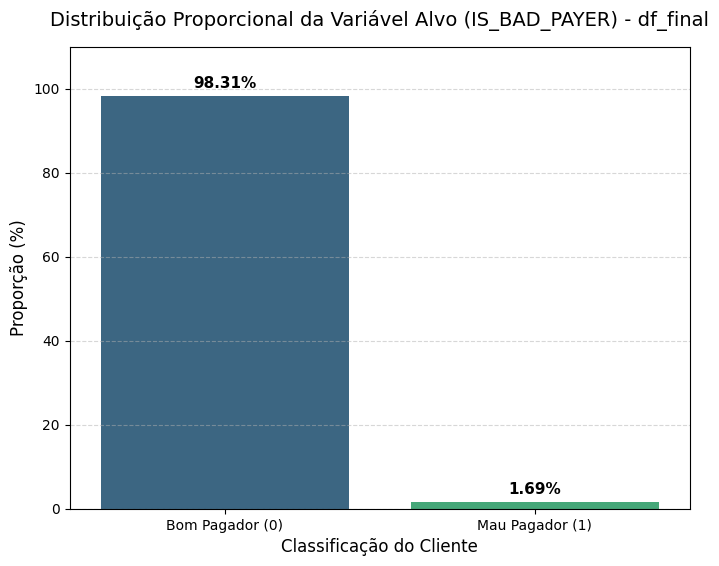

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular as proporções finais no df_final
proportions_final = df_final['IS_BAD_PAYER'].value_counts(normalize=True) * 100
proportions_df = proportions_final.reset_index()
proportions_df.columns = ['IS_BAD_PAYER', 'Proporção (%)']
proportions_df['Classe'] = proportions_df['IS_BAD_PAYER'].map({0: 'Bom Pagador (0)', 1: 'Mau Pagador (1)'})

# Configurar a visualização
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Classe', y='Proporção (%)', data=proportions_df, palette='viridis', hue='Classe', legend=False)

# Adicionar rótulos de porcentagem em cima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                weight='bold')

plt.title('Distribuição Proporcional da Variável Alvo (IS_BAD_PAYER) - df_final', fontsize=14, pad=15)
plt.xlabel('Classificação do Cliente', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.ylim(0, 110)  # Deixar espaço extra no topo para as anotações
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Análise e Interpretação do Gráfico de Distribuição Proporcional Final

A visualização acima consolida a proporção final de classes obtida após o cruzamento dos dados cadastrais com o histórico de comportamento financeiro (base consolidada `df_final`):

* **Preservação da Proporção da Classe Alvo:** A consolidação via *Inner Join* manteve a característica de desbalanceamento severo identificada no histórico bruto. A classe minoritária (**Mau Pagador - 1**) representa uma porcentagem muito pequena do total de clientes elegíveis.
* **Implicações para a Modelagem (Notebook 03):** Esta forte assimetria indica que o modelo preditivo não poderá ser treinado de forma ingênua, sob o risco de apenas prever a classe majoritária e obter uma acurácia ilusoriamente alta enquanto falha em identificar os verdadeiros inadimplentes. Portanto, as métricas primárias de avaliação do modelo deverão focar em **Recall, F1-Score** e na **Área sob a Curva Precision-Recall (PR-AUC)**, além de exigir o uso de técnicas de balanceamento de classes (como pesos de classe ou amostragem sintética) de forma isolada dentro do pipeline de treinamento.

In [34]:
# Verificar informações gerais do df_final
print("\nInformações do df_final:")
df_final.info()


Informações do df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL

## 3. Normalização / padronização

**Escolha e justificativa:** _StandardScaler, MinMaxScaler ou nenhum?_

Aplique preferencialmente dentro de um `Pipeline` no notebook 03 — ajustar o scaler antes do split vaza informação do teste para o treino.

**Escolha e Justificativa:** `StandardScaler`

Para este projeto de classificação de risco de crédito, bom ou mau pagador,a escolha foi utilizar o `StandardScaler`. O conjunto de dados apresenta variáveis com magnitudes muito distintas e a presença de alguns outliers foi mantida.

**Justificativas para o `StandardScaler`:**

1.  **Robustez a Outliers:** O `StandardScaler` reescala os dados para que tenham média zero e desvio padrão um. Embora os outliers ainda possam afetar a média e o desvio padrão, o `StandardScaler` é, em geral, **menos sensível a outliers do que o `MinMaxScaler`**. Se usássemos o `MinMaxScaler`, que reescala os dados para um intervalo fixo (e.g., [0,1]) usando os valores mínimos e máximos observados, a presença de outliers extremos poderia comprimir a maioria dos dados em uma faixa muito pequena desse intervalo, diminuindo a variabilidade útil das features. O `StandardScaler`, por não limitar os dados a um intervalo fixo, permite que os outliers mantenham sua distância relativa, o que pode ser benéfico dependendo do algoritmo.

2.  **Generalidade e Ampla Aplicabilidade:** Muitos algoritmos de Machine Learning (como Regressão Linear, Regressão Logística, SVMs, Redes Neurais, K-Means e PCA) funcionam melhor ou convergem mais rapidamente quando as features estão padronizadas para terem média zero e variância unitária.

3.  **Preservação de Informações da Distribuição:** Ao centralizar os dados em zero e escalá-los pela variância, o `StandardScaler` ajuda a mitigar o impacto de diferentes escalas sem distorcer significativamente a forma da distribuição original dos dados (ao contrário de transformações não-lineares, que alteram a distribuição). Isso é importante para algoritmos que se beneficiam da estrutura da distribuição dos dados.

**Por que não `MinMaxScaler`?**

Embora o `MinMaxScaler` seja útil para algoritmos que exigem entradas em um intervalo estritamente definido (como algumas redes neurais com funções de ativação específicas), sua alta sensibilidade a outliers o torna menos ideal neste cenário, onde decidimos manter alguns desses valores extremos. Um único outlier pode distorcer drasticamente a escala, fazendo com que a maioria dos dados fique 'espremida' em uma pequena parte do novo intervalo.

**Implementação no `Pipeline` (Notebook 03):**

Conforme mencionado, é crucial aplicar o `StandardScaler` corretamente para evitar **vazamento de dados (data leakage)**. O processo de 'ajuste' (fit) do scaler (onde ele calcula a média e o desvio padrão) deve ser realizado **exclusivamente no conjunto de dados de treino**. Posteriormente, o scaler 'treinado' será usado para 'transformar' tanto os dados de treino quanto os dados de teste.

Para garantir essa separação rigorosa e automatizar o processo, o `StandardScaler` será integrado a um `Pipeline` no Notebook 03, conforme orientado no enunciado dessa etapa 03. Isso assegura que nenhuma informação do conjunto de teste contamine o processo de reescalonamento, resultando em uma avaliação mais honesta e precisa da performance do modelo.

## 4. Feature engineering

A criação de novas features (engenharia de features) é um passo crucial para melhorar o poder preditivo dos modelos de Machine Learning, pois permite que o modelo capture relações e padrões nos dados que as features originais talvez não expressassem diretamente.

Além disso, a transformação de variáveis categóricas em numéricas é essencial, já que a maioria dos algoritmos de ML opera apenas com dados numéricos.

Para enriquecer o modelo e capturar relações mais complexas nos dados, criaremos as seguintes novas features:

INCOME_PER_PERSON (Renda por Pessoa da Família):

Cálculo: AMT_INCOME_TOTAL / CNT_FAM_MEMBERS
Justificativa: A renda total (AMT_INCOME_TOTAL) é um fator importante, mas a capacidade de um indivíduo de honrar seus compromissos financeiros pode ser mais precisamente avaliada ao considerar quantas pessoas dependem dessa renda. Uma renda alta distribuída entre muitos membros da família pode indicar menor folga financeira por indivíduo, enquanto a mesma renda para uma família menor sugere maior capacidade de pagamento. Esta feature normaliza a renda pelo tamanho da família, oferecendo uma perspectiva de renda per capita que pode ser um indicador mais robusto de estabilidade financeira e risco de crédito.

HAS_CHILDREN (Possui Filhos):

Cálculo: Binário (1 se CNT_CHILDREN > 0, 0 caso contrário)
Justificativa: A presença de filhos (CNT_CHILDREN > 0) pode influenciar significativamente as responsabilidades financeiras de um indivíduo. Famílias com filhos geralmente têm despesas mais elevadas, o que pode impactar sua capacidade de pagamento de dívidas. Embora CNT_CHILDREN já exista, uma feature binária explícita pode simplificar a interpretação para alguns modelos e destacar a diferença fundamental entre ter ou não ter filhos, independentemente do número exato de crianças.

In [35]:
# Criar features de proporção de histórico de crédito
df_final['INCOME_PER_PERSON'] = df_final['AMT_INCOME_TOTAL'] / df_final['CNT_FAM_MEMBERS']
df_final['HAS_CHILDREN'] = (df_final['CNT_CHILDREN'] > 0).astype(int)

In [36]:
df_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,IS_BAD_PAYER,INCOME_PER_PERSON,HAS_CHILDREN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,213750.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0,213750.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3,0,56250.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0,270000.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0,270000.0,0


Tratamento de Variáveis Categóricas

Para preparar os dados para modelagem, é necessário converter as variáveis categóricas para um formato numérico. Serão aplicadas as seguintes estratégias:

*   **Variáveis Categóricas Binárias:** Mapeadas diretamente para 0 e 1, criando novas colunas para as versões codificadas.
*   **Variáveis Categóricas Não-Binárias:** Utilizado One-Hot Encoding para criar novas colunas binárias para cada categoria, evitando a criação de uma ordem artificial entre as categorias.

In [37]:
# Fazer uma cópia do Dataframe.
df_processed = df_final.copy()

# Mapear variáveis categóricas binárias para numéricas.
df_processed["CODE_GENDER"] = df_processed["CODE_GENDER"].map({"M": 1, "F": 0})
df_processed["FLAG_OWN_CAR"] = df_processed["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_processed["FLAG_OWN_REALTY"] = df_processed["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})

# Identificar colunas categóricas restantes que não são binárias para One-Hot Encoding
categorical_cols_to_encode = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Aplicar One-Hot Encoding para as variáveis categóricas restantes
# e juntar as colunas codificadas ao df_processed, removendo as colunas originais.
df_final_encoded = pd.get_dummies(df_processed, columns=categorical_cols_to_encode, prefix=categorical_cols_to_encode, drop_first=True)

#Remover a coluna 'ID', 'FLAG_MOBIL' e 'IS_BAD_PAYER' já que não são relevantes
# para a previsão,
colunas_para_descartar = ["ID", "DAYS_BIRTH", "DAYS_EMPLOYED", "FLAG_MOBIL"]
df_final_encoded = df_final_encoded.drop(columns=colunas_para_descartar)
print("df_final_encoded após o tratamento das variáveis categóricas:")
display(df_final_encoded.head())
display(df_final_encoded.info())

df_final_encoded após o tratamento das variáveis categóricas:


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,IS_BAD_PAYER,INCOME_PER_PERSON,HAS_CHILDREN,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,1,1,1,0,427500.0,1,0,0,2.0,32,0,12,0,213750.0,0,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,1,1,0,427500.0,1,0,0,2.0,32,0,12,0,213750.0,0,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,1,1,0,112500.0,0,0,0,2.0,58,0,3,0,56250.0,0,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,0,0,1,0,270000.0,0,1,1,1.0,52,0,8,0,270000.0,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,0,0,1,0,270000.0,0,1,1,1.0,52,0,8,0,270000.0,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 50 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   CODE_GENDER                                        36457 non-null  int64  
 1   FLAG_OWN_CAR                                       36457 non-null  int64  
 2   FLAG_OWN_REALTY                                    36457 non-null  int64  
 3   CNT_CHILDREN                                       36457 non-null  int64  
 4   AMT_INCOME_TOTAL                                   36457 non-null  float64
 5   FLAG_WORK_PHONE                                    36457 non-null  int64  
 6   FLAG_PHONE                                         36457 non-null  int64  
 7   FLAG_EMAIL                                         36457 non-null  int64  
 8   CNT_FAM_MEMBERS                                    36457 non-null  float64
 9   YEARS_

None

Considerações Finais sobre Pré-processamento: Outliers e Balanceamento de Classes

É importante ressaltar que, nesta etapa de pré-processamento (Notebook 02), algumas técnicas comuns não foram aplicadas, especificamente:

*   **Tratamento de Outliers (Capping):** A decisão de não aplicar o capping para outliers neste momento é estratégica. Embora a presença de valores extremos possa influenciar alguns modelos, a remoção ou transformação precoce de outliers pode levar à perda de informações valiosas ou à criação de um viés artificial, especialmente antes da divisão dos dados em conjuntos de treino e teste. Além disso, a aplicação de técnicas de capping é mais robusta quando realizada dentro de um `Pipeline` de pré-processamento no notebook 03, garantindo que o ajuste dos limites de capping ocorra apenas nos dados de treino, evitando assim o **vazamento de dados (data leakage)** do conjunto de teste. (Obs.: os outliers foram tratados na etapa "04 Outliers" do notebook 01, para responder tal tópico do trabalho, porém os códigos não foram trazidos para esse notebook 02.)  

*   **Balanceamento de Classes:** O conjunto de dados apresenta um desequilíbrio de classes significativo para a variável alvo `IS_BAD_PAYER`, conforme observado na seção de definição da variável alvo. No entanto, o balanceamento de classes (usando técnicas como oversampling, undersampling ou SMOTE) não foi realizado nesta fase. A principal razão para isso é evitar o **vazamento de dados**. Técnicas de balanceamento, especialmente oversampling, criam novas amostras baseadas nos dados existentes. Se aplicadas antes da divisão treino-teste, as amostras sintéticas criadas podem "ver" informações do conjunto de teste, levando a uma superestimação da performance do modelo.

Ambas as medidas — o tratamento de outliers (se considerado necessário após análise mais aprofundada) e o balanceamento de classes — serão consideradas e implementadas no **Notebook 03**, dentro de um `Pipeline` de pré-processamento. Isso garantirá que todas as transformações de dados sejam aplicadas de maneira apropriada, prevenindo o vazamento de informações e resultando em uma avaliação de modelo mais justa e confiável.

## 5. Salvar dataset tratado

In [38]:
PROCESSED.mkdir(parents=True, exist_ok=True)
df_final_encoded.to_csv(PROCESSED / "dataset_tratado.csv", index=False)
df_final.to_csv(PROCESSED / "df_final.csv", index=False)